# Customer Segmentation Using K-Means Clustering

## Objective

The objective of this project is to analyze customer purchasing behavior and segment customers into distinct groups using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering. These customer segments help businesses understand buying patterns, improve customer retention, develop personalized marketing campaigns, and make data-driven business decisions.

## Dataset Overview

The Online Retail dataset contains transactional records of a UK-based online retail company. It includes customer purchases made between 2010 and 2011 and consists of 541,910 transactions across eight features such as Invoice Number, Product Description, Quantity, Unit Price, Customer ID, and Country.

This dataset is suitable for customer segmentation because it captures customer purchasing behavior over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
df = pd.read_excel("Online Retail.xlsx")

## Data Cleaning

Before performing customer segmentation, the dataset was cleaned to ensure data quality.

The following preprocessing steps were performed:

- Removed missing Customer IDs.
- Excluded cancelled invoices.
- Removed records with negative quantities.
- Removed records with zero or negative unit prices.
- Created a new Revenue column.
- Converted InvoiceDate into datetime format.

These steps ensure that only valid customer transactions are used for analysis.

In [3]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


np.int64(5268)

In [4]:
df.dropna(inplace=True)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [5]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

## Feature Engineering

A new feature named Revenue was created by multiplying Quantity with UnitPrice.

Revenue = Quantity × UnitPrice

This feature represents the total spending made during each transaction and plays an important role in measuring customer value.

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [9]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Analysis

RFM (Recency, Frequency, Monetary) is a customer behavior analysis technique used to evaluate customer value.

- Recency measures how recently a customer made a purchase.
- Frequency measures how often a customer makes purchases.
- Monetary measures how much money the customer spends.

These three features provide a strong foundation for customer segmentation.

In [10]:
rfm.describe()
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

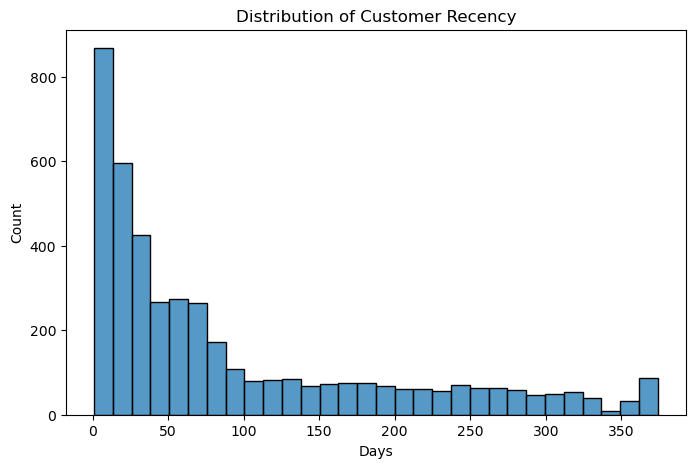

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=30)
plt.title("Distribution of Customer Recency")
plt.xlabel("Days")
plt.show()

### Observation

The distribution indicates that most customers made purchases recently, while a smaller group has not purchased for a long period. Customers with higher recency values may require re-engagement strategies.

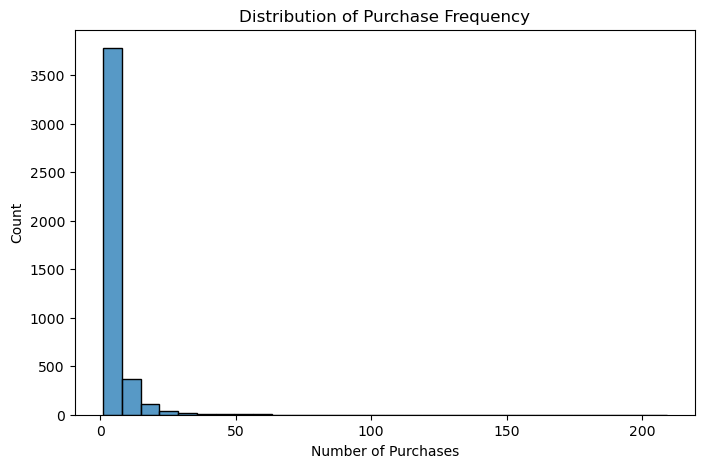

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'], bins=30)
plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.show()

### Observation

Most customers purchase only a few times, whereas a small number of customers purchase frequently. These frequent buyers represent valuable customers for the business.

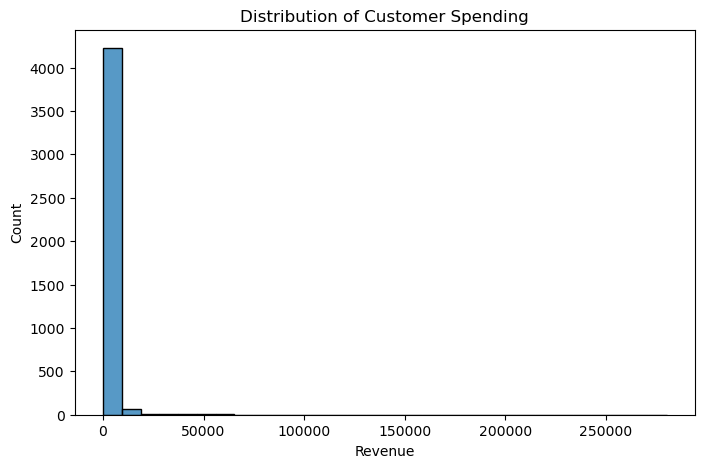

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=30)
plt.title("Distribution of Customer Spending")
plt.xlabel("Revenue")
plt.show()

### Observation

Customer spending is positively skewed, indicating that while most customers make moderate purchases, a small group contributes significantly higher revenue.

In [14]:
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return column.clip(lower, upper)
rfm['Recency'] = cap_outliers(rfm['Recency'])
rfm['Frequency'] = cap_outliers(rfm['Frequency'])
rfm['Monetary'] = cap_outliers(rfm['Monetary'])

In [15]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.413382,-0.818035,2.204224
12347.0,-0.920352,1.155805,2.204224
12348.0,-0.169233,0.168885,0.552579
12349.0,-0.745433,-0.818035,0.518004
12350.0,2.248753,-0.818035,-0.721739


In [17]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

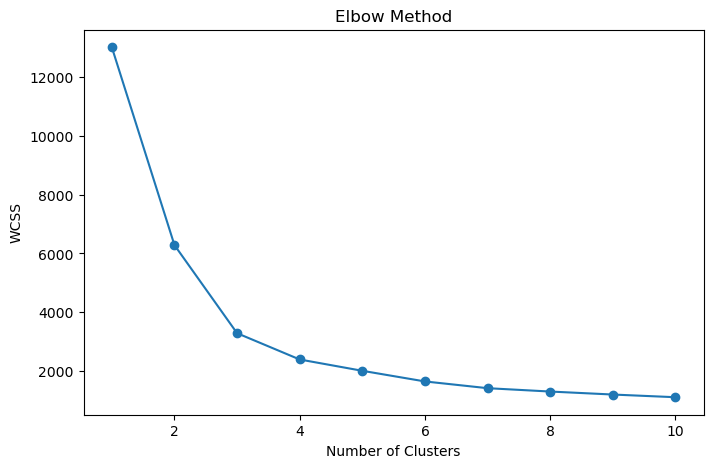

In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of customer clusters.

The graph shows a significant reduction in WCSS up to four clusters, after which the improvement becomes marginal. Therefore, four clusters were selected for the K-Means clustering model.

In [19]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [20]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,3693.2275,2
12347.0,2,7,3693.2275,3
12348.0,75,4,1797.2400,0
12349.0,19,1,1757.5500,1
12350.0,310,1,334.4000,2


In [21]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'count']
})
cluster_summary

Recency        Frequency            Monetary                 
               mean median      mean median         mean     median count
Cluster                                                                  
0         39.973036   26.0  4.981243    5.0  1954.087182  1793.5800   853
1         53.004195   45.0  1.981647    2.0   541.852865   471.5100  1907
2        248.679602  248.0  1.448756    1.0   410.908072   305.7800  1005
3         20.244328   10.0  9.844677   11.0  3371.032539  3693.2275   573

In [22]:
cluster_names = {
    0: 'Loyal Customers',
    1: 'Regular Customers',
    2: 'At-Risk Customers',
    3: 'High Value Customers'
}

rfm['Customer Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer Segment
CustomerID,,,,,
12346.0,326,1,3693.2275,2,At-Risk Customers
12347.0,2,7,3693.2275,3,High Value Customers
12348.0,75,4,1797.2400,0,Loyal Customers
12349.0,19,1,1757.5500,1,Regular Customers
12350.0,310,1,334.4000,2,At-Risk Customers


## Cluster Interpretation

Based on Recency, Frequency, and Monetary values, four distinct customer segments were identified.
Each cluster represents customers with different purchasing behaviors and business value.

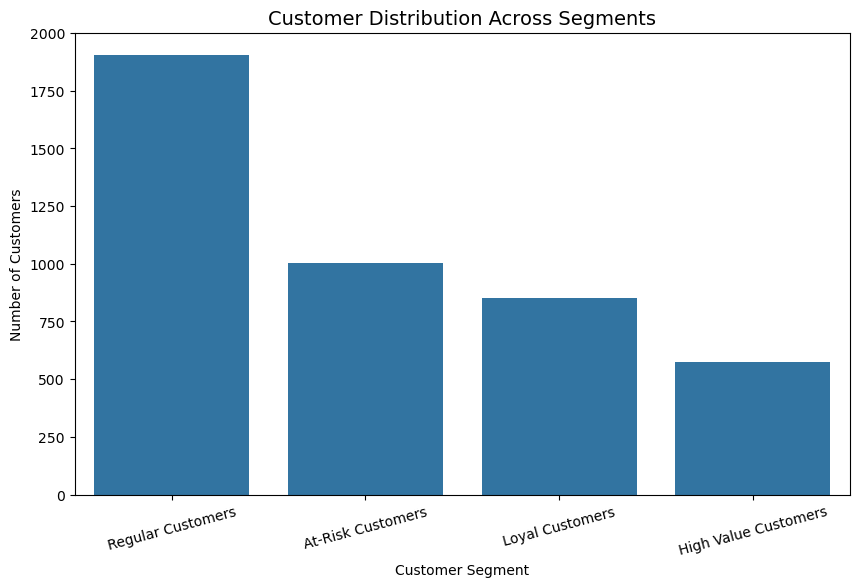

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=rfm,
    x='Customer Segment',
    order=rfm['Customer Segment'].value_counts().index
)
plt.title("Customer Distribution Across Segments", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

### Observation

Regular Customers form the largest customer segment, while High Value Customers represent a smaller but highly profitable group. This indicates that a small percentage of customers contribute a significant portion of the revenue.

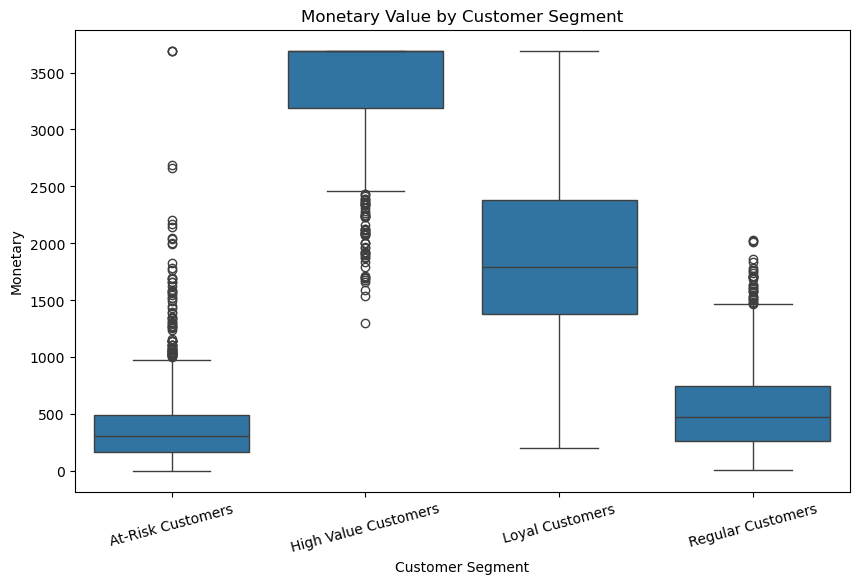

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=rfm,
    x='Customer Segment',
    y='Monetary'
)
plt.title("Monetary Value by Customer Segment")
plt.xticks(rotation=15)
plt.show()

### Observation

High Value Customers generate the highest revenue compared to other customer groups. At-Risk Customers contribute the least revenue, highlighting opportunities for targeted retention campaigns.

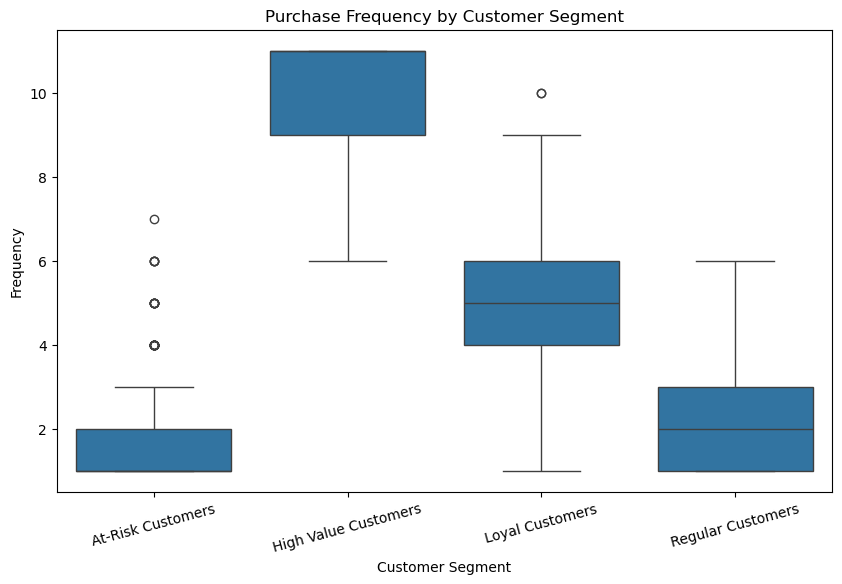

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=rfm,
    x='Customer Segment',
    y='Frequency'
)
plt.title("Purchase Frequency by Customer Segment")
plt.xticks(rotation=15)
plt.show()

### Observation

High Value Customers purchase much more frequently than other customer segments. Their consistent purchasing behavior makes them ideal candidates for loyalty and reward programs.

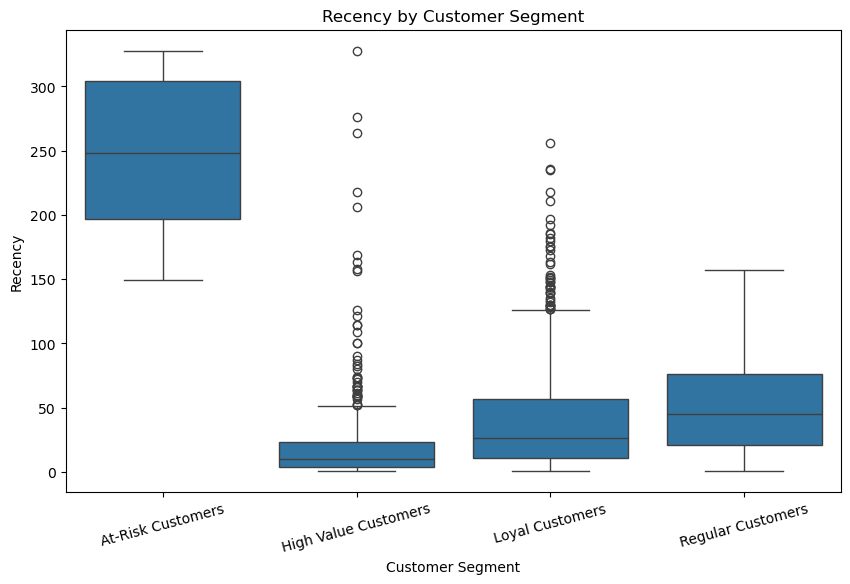

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=rfm,
    x='Customer Segment',
    y='Recency'
)
plt.title("Recency by Customer Segment")
plt.xticks(rotation=15)
plt.show()

### Observation

At-Risk Customers have the highest recency values, meaning they have not purchased for a long time. Businesses should focus on re-engaging these customers through personalized offers and promotional campaigns.

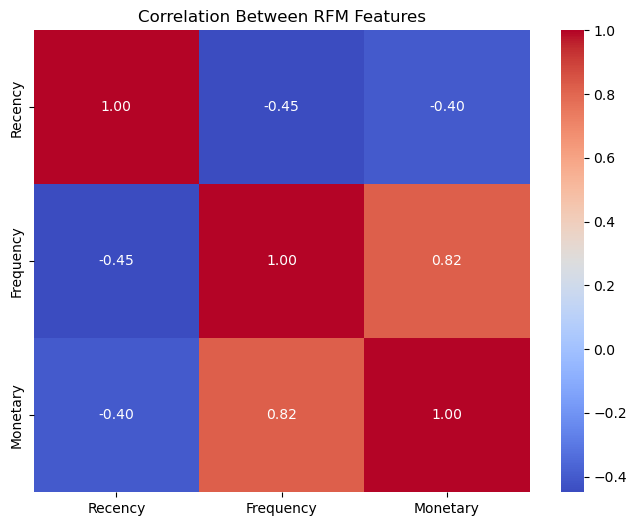

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Between RFM Features")
plt.show()

### Observation

The correlation matrix shows that Frequency and Monetary have a positive relationship, indicating that customers who purchase more frequently generally spend more. Recency has a negative relationship with both Frequency and Monetary, suggesting that recently active customers tend to purchase more often and spend more.

In [28]:
rfm.to_csv("Customer_Segmentation_Result.csv")

# Business Insights

- High Value Customers generate the highest revenue and should be prioritized through exclusive loyalty programs and premium customer services.

- Loyal Customers contribute consistent revenue and should be retained through personalized product recommendations and reward programs.

- Regular Customers represent the largest customer base and have the potential to become loyal customers with targeted marketing strategies.

- At-Risk Customers require immediate attention through re-engagement campaigns, discount offers, and personalized communication to reduce customer churn.

- Customer segmentation enables businesses to allocate marketing resources more effectively and improve customer satisfaction.

# Recommendations

1. Develop exclusive loyalty programs for High Value Customers to maximize long-term retention.

2. Offer personalized product recommendations to Loyal Customers based on their purchase history.

3. Encourage Regular Customers to increase purchase frequency through promotional discounts, bundled offers, and seasonal campaigns.

4. Launch targeted email and SMS campaigns for At-Risk Customers with personalized discounts and special incentives.

5. Continuously monitor customer behavior and update customer segments periodically to improve marketing effectiveness.

6. Integrate customer segmentation into Customer Relationship Management (CRM) systems to support personalized communication and improve customer experience.

7. Utilize predictive analytics to identify customers who are likely to become At-Risk and take proactive retention measures.

# Conclusion

This project successfully applied RFM analysis and K-Means clustering to segment customers based on their purchasing behavior.

Four meaningful customer segments—High Value Customers, Loyal Customers, Regular Customers, and At-Risk Customers—were identified using Recency, Frequency, and Monetary metrics.

The findings demonstrate that customer segmentation is an effective approach for understanding customer behavior, optimizing marketing strategies, improving customer retention, and increasing overall business profitability.

Overall, this project showcases the practical application of data analytics and machine learning techniques in solving real-world business problems and supports data-driven decision-making.